# PLS baseline
> PLS regression of δ13C on SNV and first-derivative spectra, scored on random and leave-one-batch-out splits

This notebook fits a PLS regression baseline and scores it in three ways. A random split stratified by batch tests predictions for new samples from batches the model has seen. Leave-one-batch-out tests predictions for a batch the model has never seen. The within-batch R² measures how well the model ranks samples inside each batch.

Batch alone explains 68% of the δ13C variance (see the EDA notebook). A random-split R² near 0.68 therefore shows no skill beyond recognising the batch.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneGroupOut, cross_val_predict
from sklearn.pipeline import make_pipeline
from soilspectfm.all import *
from fastcore.test import *
from cassava.data import *

In [ ]:
#| eval: false
d = load_data('../data')

## Metrics

In [ ]:
def within_r2(
    y, # Observed values
    yhat, # Predicted values
    groups, # Group of each sample
):
    "R² of `yhat` against `y` after centring both on their group means"
    yc, pc = (pd.Series(v).groupby(np.asarray(groups)).transform(lambda s: s - s.mean()) for v in (y, yhat))
    return 1 - ((yc - pc)**2).sum() / (yc**2).sum()

A model that predicts only the batch means scores a high R² and a within-batch R² of 0:

In [ ]:
y, g = np.array([1., 2, 5, 6]), np.array(['a', 'a', 'b', 'b'])
means = np.array([1.5, 1.5, 5.5, 5.5])
test_eq(within_r2(y, means, g), 0)
r2_score(y, means)

0.9411764705882353

In [ ]:
def metrics(
    y, # Observed values
    yhat, # Predicted values
    groups, # Group of each sample
) -> dict:
    "R², RMSE and within-group R² of `yhat` against `y`"
    return dict(r2=r2_score(y, yhat), rmse=root_mean_squared_error(y, yhat), within_r2=within_r2(y, yhat, groups))

In [ ]:
def per_batch(
    y, # Observed values
    yhat, # Predicted values
    groups, # Group of each sample
) -> pd.DataFrame:
    "Sample count, RMSE, bias, R², within-group R² and correlation of `yhat` against `y` in each group"
    rows = {}
    for b in np.unique(groups):
        m = groups == b
        yb, pb = y[m], yhat[m]
        fit = dict(r2=r2_score(yb, pb), within_r2=within_r2(yb, pb, groups[m]), r=np.corrcoef(yb, pb)[0, 1])
        rows[b] = dict(n=m.sum(), rmse=root_mean_squared_error(yb, pb), bias=(pb - yb).mean(), **fit)
    return pd.DataFrame(rows).T

## Model

The pipeline first keeps the wavenumbers up to `w_max`. It then applies SNV, a Savitzky-Golay first derivative with a 15-point window and a cubic polynomial, and PLS regression. PLS runs with `scale=False`, because all the features are absorbances on one scale.

The notebook compares two versions of the spectra. `full` keeps every wavenumber. `trimmed` drops everything above 3550 cm⁻¹, which removes the water vapour region found in the EDA notebook.

In [ ]:
def pls(
    n, # Number of PLS components
    ws, # Wavenumbers (cm⁻¹)
    w_max=None, # Highest wavenumber to keep (cm⁻¹); `None` keeps all
):
    "Trim, SNV, Savitzky-Golay first derivative and PLS regression with `n` components"
    return make_pipeline(Trim(ws, w_max=w_max), SNV(), SavitzkyGolay(deriv=1), PLSRegression(n_components=n, scale=False))

## Splits

The random split uses 5 folds, stratified by batch so that each fold holds the same share of every batch. Leave-one-batch-out uses 7 folds, one per batch.

In [ ]:
#| eval: false
skf = StratifiedKFold(5, shuffle=True, random_state=0)
splits = dict(random=list(skf.split(d.X, d.batch)), lobo=list(LeaveOneGroupOut().split(d.X, groups=d.batch)))

## Number of components

Out-of-fold predictions for 1 to 20 components, for each version of the spectra and each split:

In [ ]:
#| eval: false
ns = range(1, 21)
spectra = dict(full=None, trimmed=3550)
preds = {}
for s, w in spectra.items():
    for k, cv in splits.items():
        for n in ns: preds[s, k, n] = cross_val_predict(pls(n, d.ws, w), d.X, d.y, cv=cv, n_jobs=-1).ravel()
res = pd.DataFrame([dict(spectra=s, split=k, n=n, **metrics(d.y, p, d.batch)) for (s, k, n), p in preds.items()])

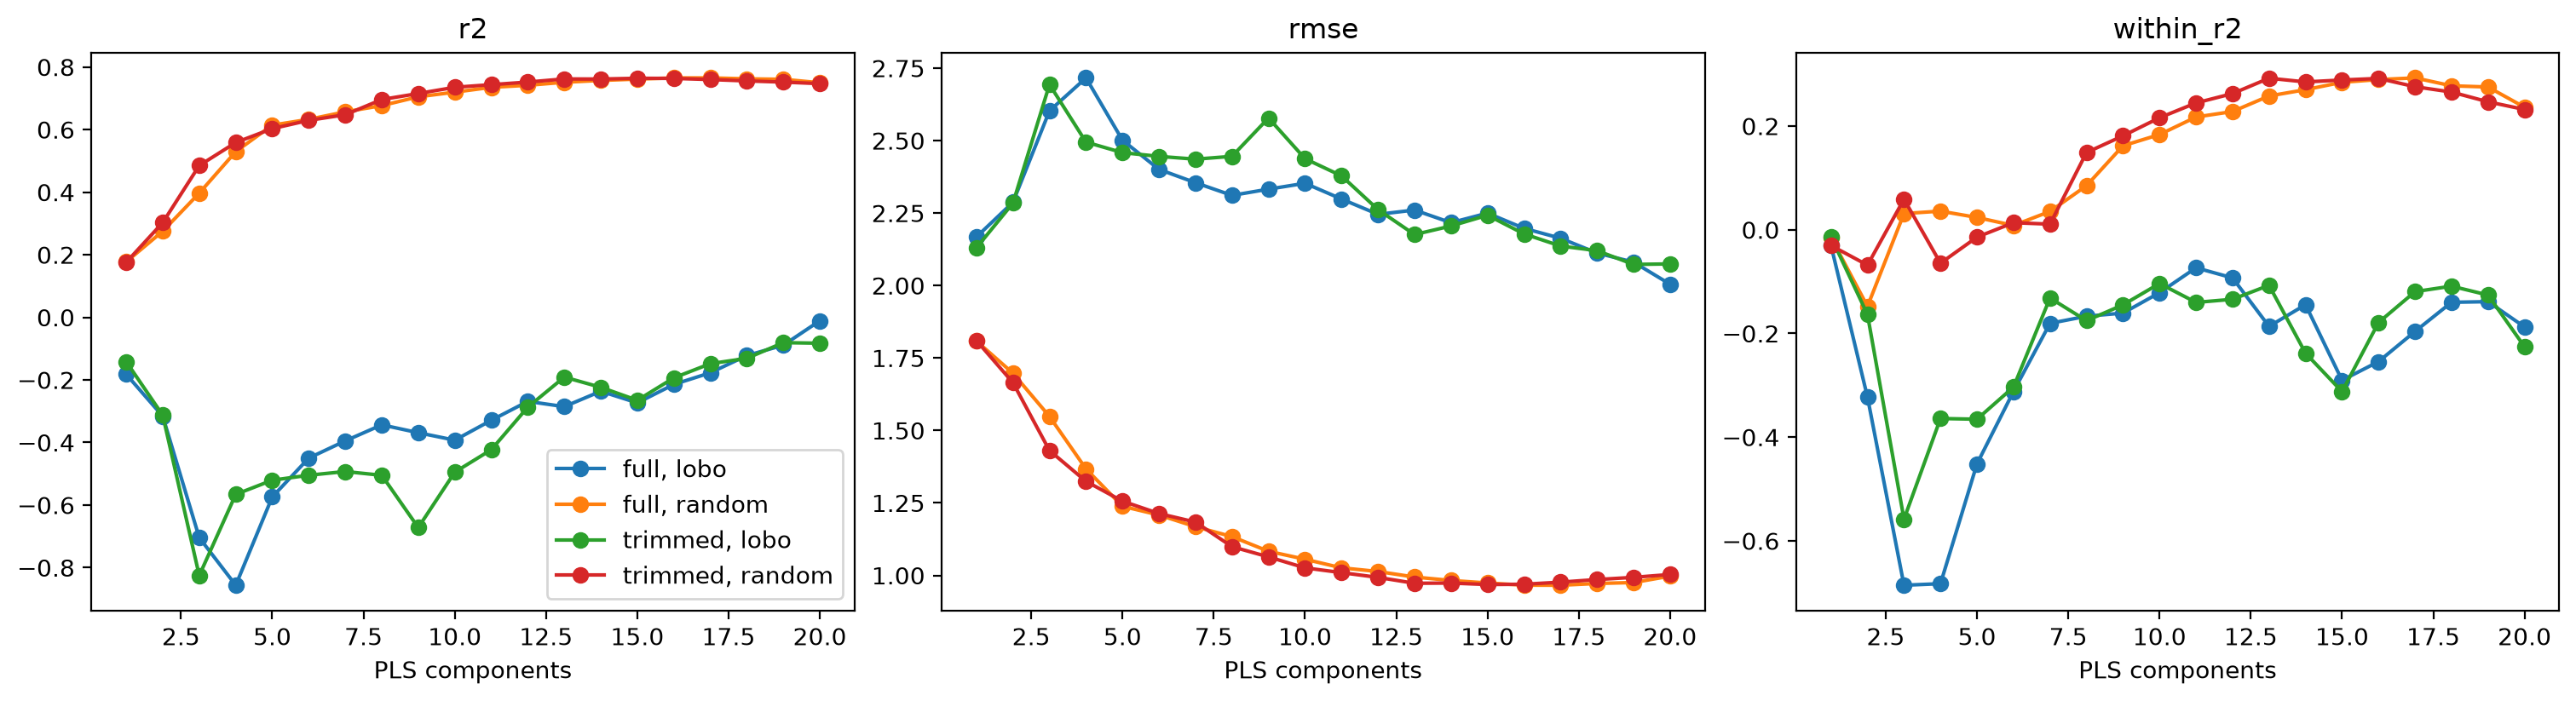

In [ ]:
#| eval: false
#| fig-column: page
fig, axs = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
for ax, m in zip(axs, ('r2', 'rmse', 'within_r2')):
    for (s, k), g in res.groupby(['spectra', 'split']): ax.plot(g.n, g[m], marker='o', label=f'{s}, {k}')
    ax.set(xlabel='PLS components', title=m)
axs[0].legend();

The number of components with the lowest RMSE, for each version of the spectra and each split, is below. The same folds choose the number of components and score the model, which makes these scores slightly optimistic.

In [ ]:
#| eval: false
best = res.loc[res.groupby(['spectra', 'split']).rmse.idxmin()].set_index(['spectra', 'split'])
best.round(3)

n     r2   rmse  within_r2
spectra split                              
full    lobo    20 -0.011  2.005     -0.188
        random  17  0.765  0.966      0.293
trimmed lobo    19 -0.081  2.073     -0.126
        random  15  0.764  0.968      0.289

## Results by batch

Leave-one-batch-out results for each held-out batch, at the best number of components for each version of the spectra. The `r2` column counts the bias as error. The `within_r2` column removes the bias first. The `r` column is the correlation between observed and predicted values inside the batch. It measures only the order of the predictions, and ignores both their level and their spread.

In [ ]:
#| eval: false
pb = {s: per_batch(d.y, preds[s, 'lobo', int(best.loc[(s, 'lobo'), 'n'])], d.batch) for s in spectra}
pd.concat(pb, axis=1).round(2)

full                              ... trimmed                            
          n  rmse  bias    r2 within_r2  ...    rmse  bias    r2 within_r2     r
1456  149.0  3.62 -3.45 -8.14      0.13  ...    3.76 -3.59 -8.87      0.13  0.41
1586  168.0  1.58  1.41 -1.53      0.48  ...    1.36  1.17 -0.88      0.50  0.73
1592  244.0  1.39  0.45 -1.66     -1.39  ...    1.69  1.13 -2.96     -1.21  0.01
1597   97.0  1.84  1.46 -4.62     -1.08  ...    2.01  1.62 -5.70     -1.34  0.04
1678  144.0  2.32 -1.38 -1.06     -0.33  ...    2.10 -1.11 -0.69     -0.21  0.06
1722  177.0  1.48  0.90 -0.81     -0.15  ...    1.63  1.13 -1.19     -0.14  0.62
1723  179.0  1.33 -0.78 -0.11      0.27  ...    1.41 -0.99 -0.25      0.37  0.63

[7 rows x 12 columns]

Within-batch R² of each held-out batch at 3, 5, 10 and 20 components, for each version of the spectra:

In [ ]:
#| eval: false
pd.DataFrame({(s, n): per_batch(d.y, preds[s, 'lobo', n], d.batch).within_r2 for s in spectra for n in (3, 5, 10, 20)}).round(2)

full                   trimmed                  
        3     5     10    20      3     5     10    20
1456  0.22  0.17 -0.06  0.13    0.08  0.10 -0.18  0.13
1586  0.21  0.04  0.38  0.48    0.16  0.02  0.35  0.49
1592 -5.31 -2.15 -0.94 -1.39   -3.32 -0.78 -0.92 -1.50
1597 -2.11 -1.98 -1.81 -1.08   -1.60 -2.90 -2.01 -1.53
1678 -0.34 -0.63 -0.33 -0.33   -0.16 -0.73 -0.20 -0.36
1722  0.12  0.15  0.19 -0.15    0.05 -0.05  0.20 -0.21
1723  0.21 -0.06  0.43  0.27   -0.52  0.09  0.49  0.31

## Observed against predicted

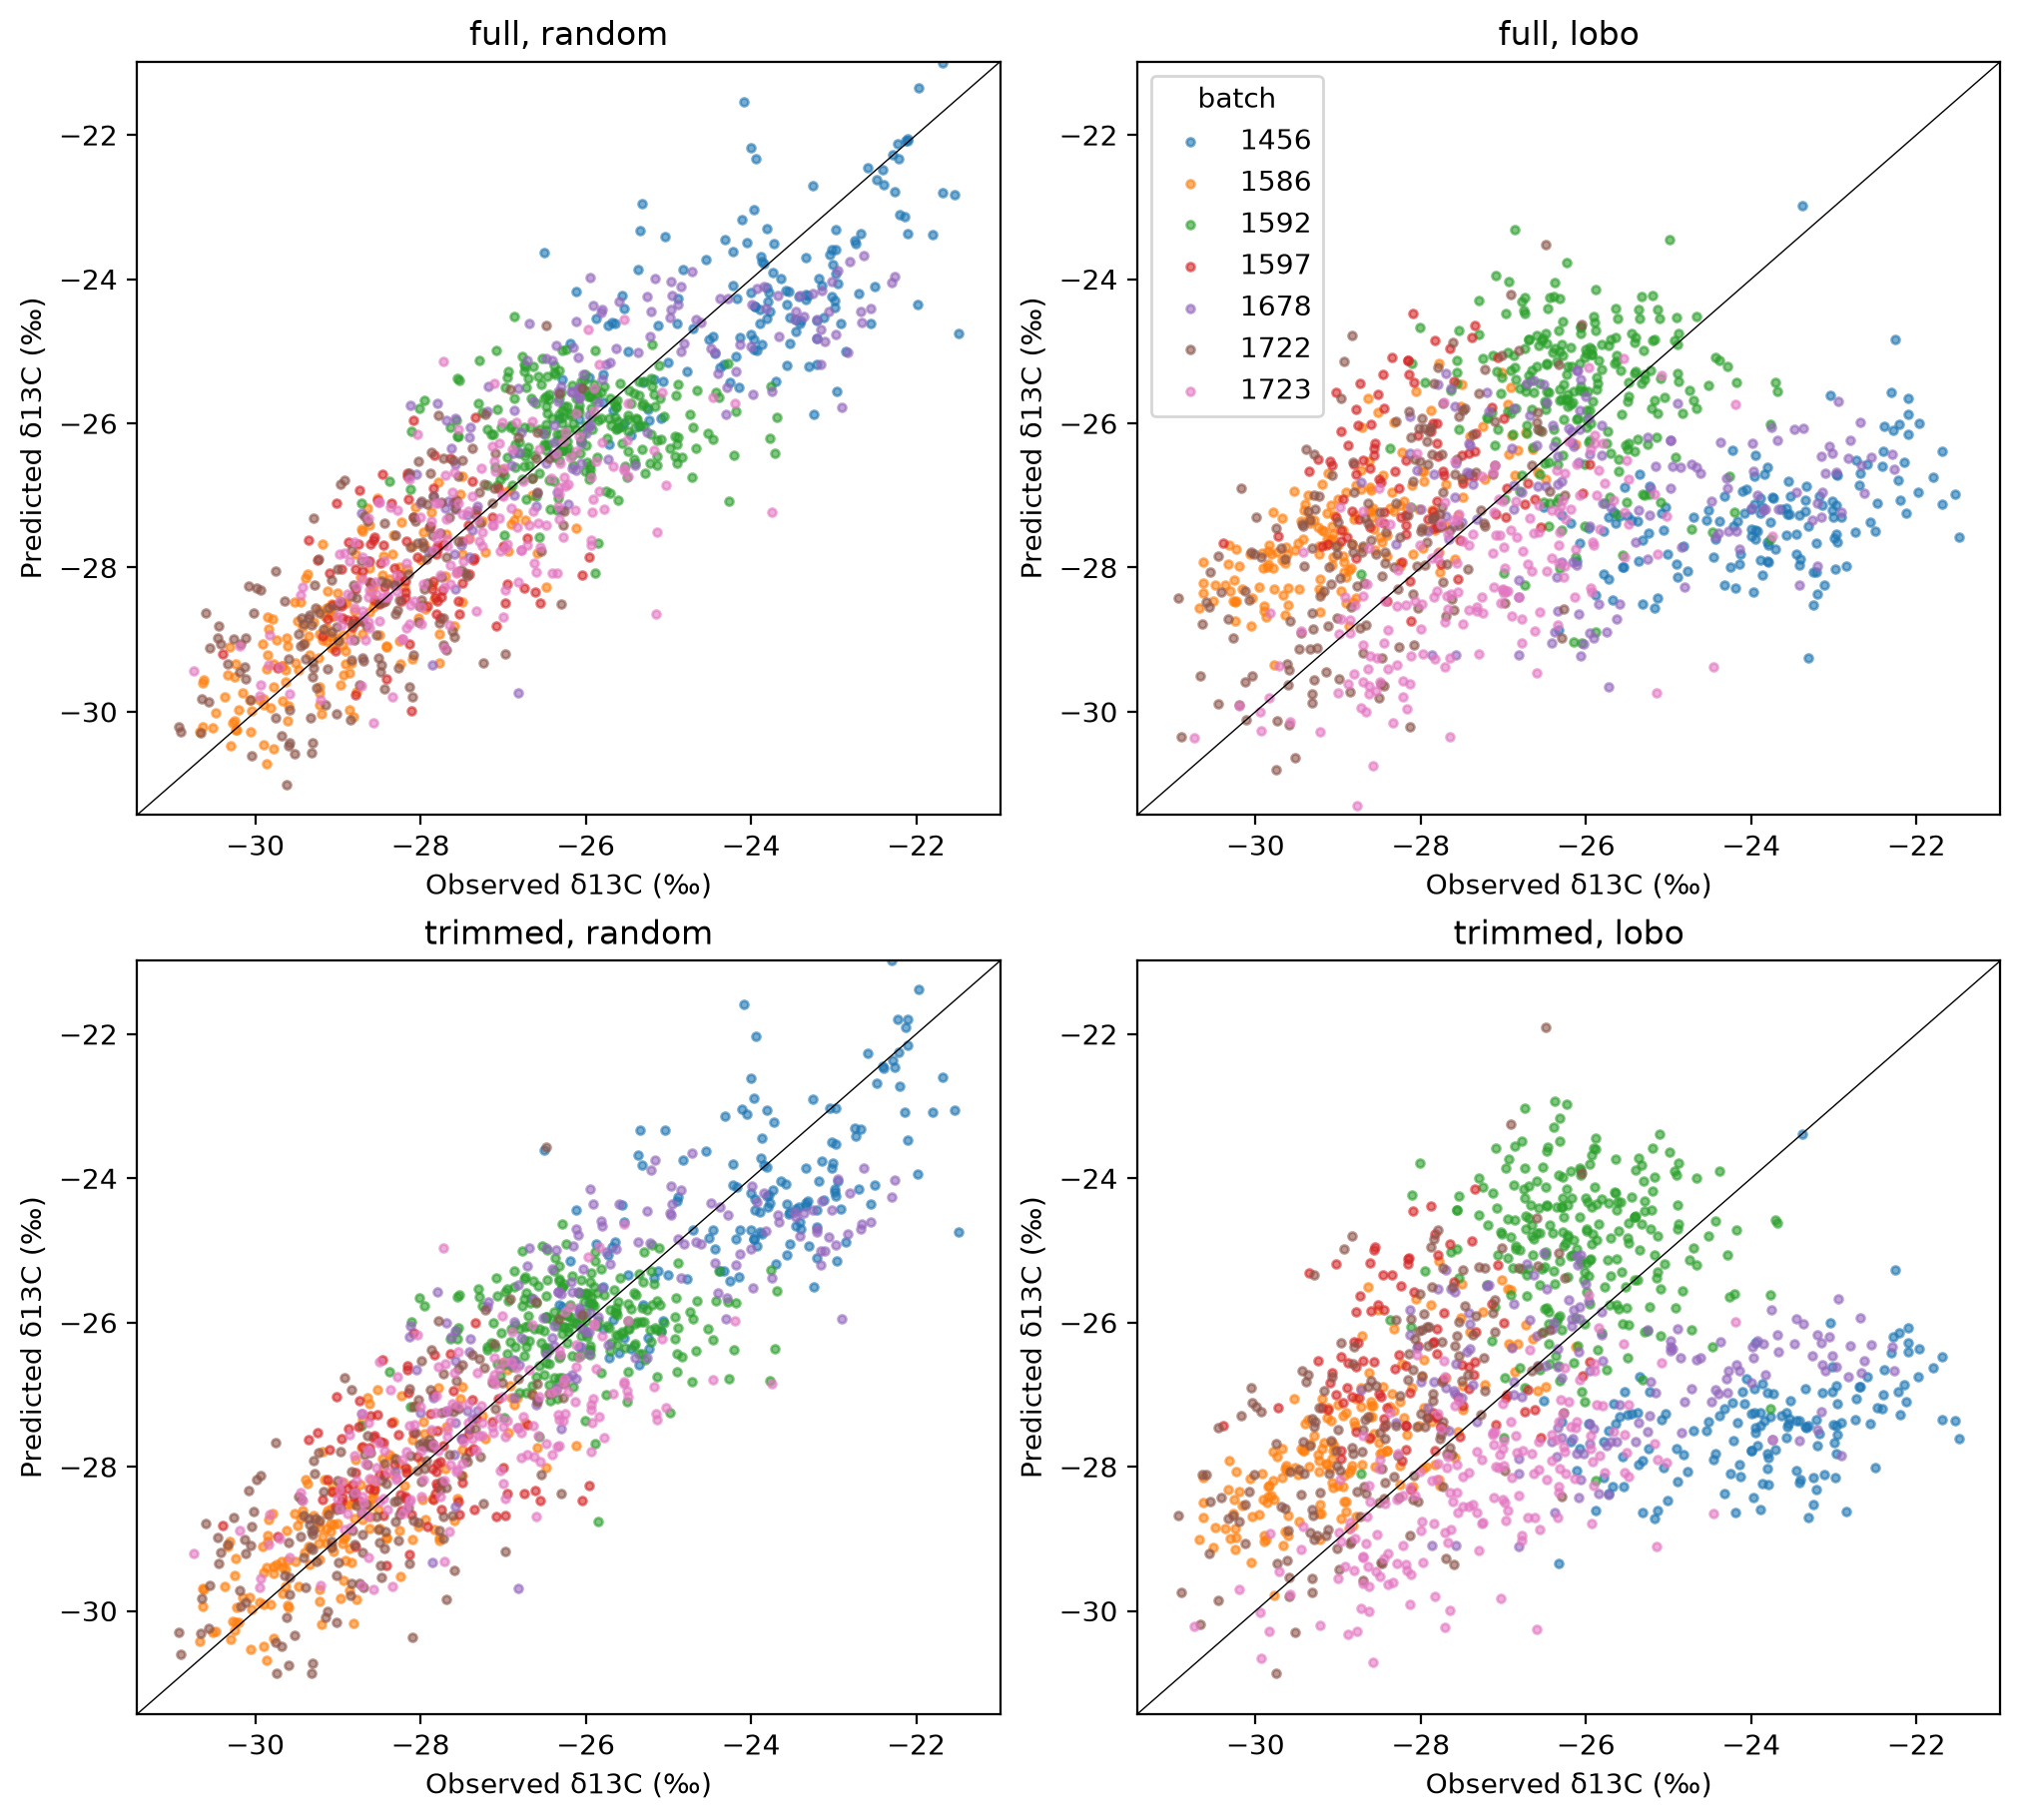

In [ ]:
#| eval: false
fig, axs = plt.subplots(2, 2, figsize=(10, 9), layout='constrained')
lims = d.y.min() - 0.5, d.y.max() + 0.5
for row, s in zip(axs, spectra):
    for ax, k in zip(row, splits):
        p = preds[s, k, int(best.loc[(s, k), 'n'])]
        for b in np.unique(d.batch): ax.scatter(d.y[d.batch == b], p[d.batch == b], s=8, alpha=0.6, label=b)
        ax.plot(lims, lims, color='k', lw=0.5)
        ax.set(title=f'{s}, {k}', xlabel='Observed δ13C (‰)', ylabel='Predicted δ13C (‰)', xlim=lims, ylim=lims)
axs[0, -1].legend(title='batch');

## Within-batch models

The global models above learn the batch levels and the variation inside batches together. The two models below learn only the variation inside batches. A local model is fitted on one batch and cross-validated inside it. The pooled model is fitted on all batches at once, after each batch is centred on its own mean spectrum and mean δ13C.

Both models need δ13C measurements from the batch they predict. The local model needs them for training. The pooled model needs them to set the batch level. Their scores show whether the spectra carry δ13C information once the batch effect is removed.

SNV and the Savitzky-Golay derivative act on each spectrum on its own, so they run once on all samples, before any split:

In [ ]:
#| eval: false
Xp = make_pipeline(SNV(), SavitzkyGolay(deriv=1)).fit_transform(d.X)

### Local models

Each batch gets 5-fold cross-validation inside it, for 1 to 15 components:

In [ ]:
#| eval: false
kf = KFold(5, shuffle=True, random_state=0)
local = {}
for b in np.unique(d.batch):
    m = d.batch == b
    for n in range(1, 16): local[b, n] = cross_val_predict(PLSRegression(n, scale=False), Xp[m], d.y[m], cv=kf).ravel()
lres = pd.DataFrame([dict(batch=b, n=n, r2=r2_score(d.y[d.batch == b], p)) for (b, n), p in local.items()])

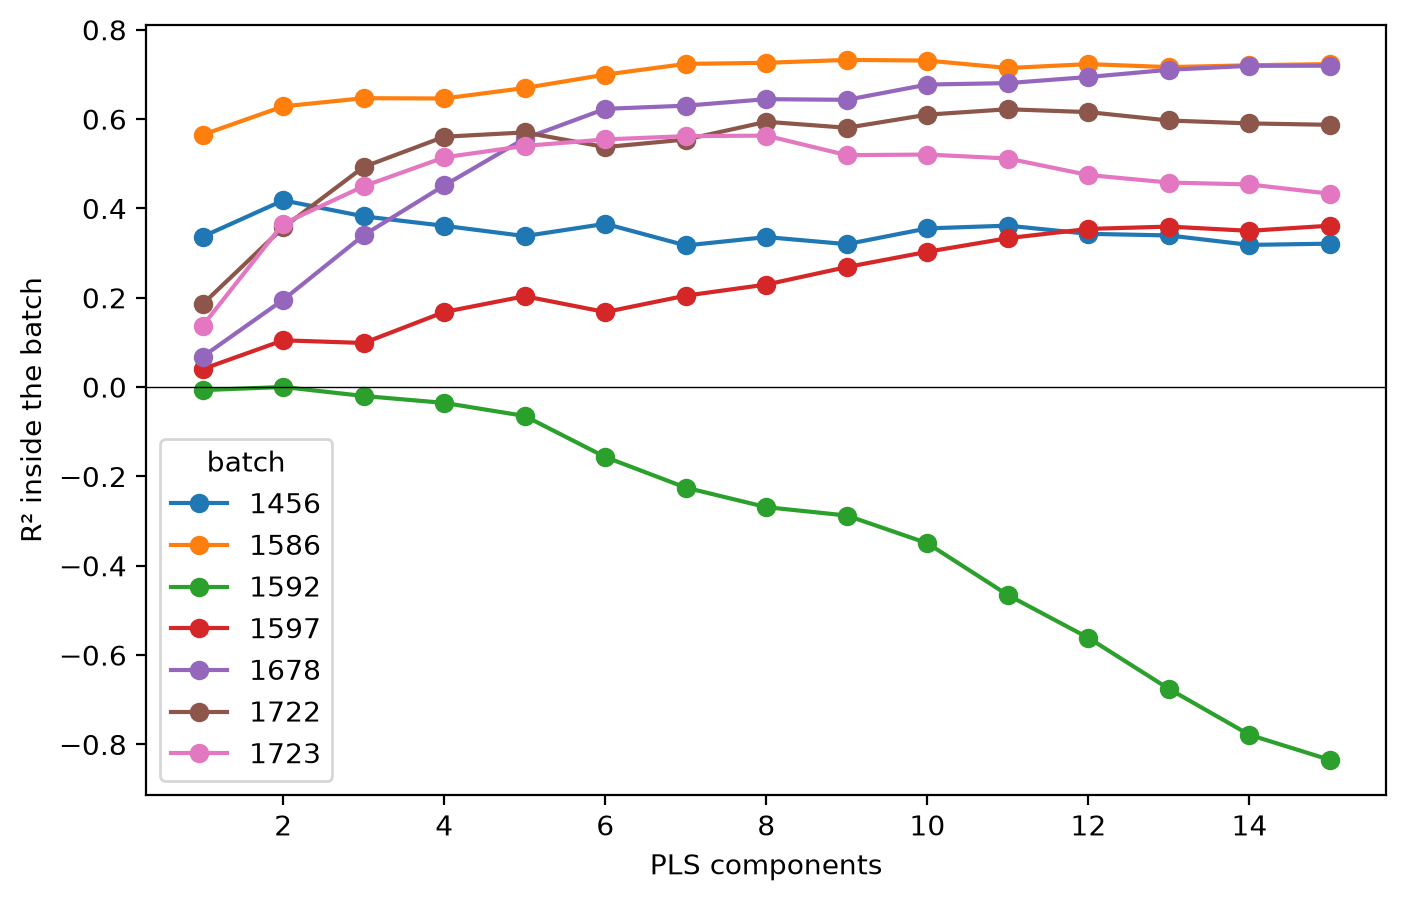

In [ ]:
#| eval: false
fig, ax = plt.subplots(figsize=(8, 5))
for b, g in lres.groupby('batch'): ax.plot(g.n, g.r2, marker='o', label=b)
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='PLS components', ylabel='R² inside the batch')
ax.legend(title='batch');

The best number of components for each local model. Choosing it on the same folds makes these scores slightly optimistic:

In [ ]:
#| eval: false
lbest = lres.loc[lres.groupby('batch').r2.idxmax()].set_index('batch')
lbest.round(2)

,n,r2
batch,,
1456,2,0.42
1586,9,0.73
1592,2,0.00
1597,15,0.36
1678,15,0.72
1722,11,0.62
1723,8,0.56


### Pooled within-batch model

`pooled_within` computes the batch means on the training samples of each fold, and applies them to the test samples of that fold. The test samples never contribute to the means.

In [ ]:
def pooled_within(
    X, # Preprocessed spectra, one per row
    y, # Observed values
    groups, # Group of each sample
    cv, # List of `(train, test)` index pairs
    n, # Number of PLS components
):
    "Out-of-fold predictions of a PLS model fitted on group-centred spectra and values"
    p = np.zeros(len(y))
    for tr, te in cv:
        mx = pd.DataFrame(X[tr]).groupby(groups[tr]).mean()
        my = pd.Series(y[tr]).groupby(groups[tr]).mean()
        pls_ = PLSRegression(n, scale=False).fit(X[tr] - mx.loc[groups[tr]].values, y[tr] - my[groups[tr]].values)
        p[te] = pls_.predict(X[te] - mx.loc[groups[te]].values).ravel() + my[groups[te]].values
    return p

Out-of-fold predictions on the random split, for 1 to 20 components:

In [ ]:
#| eval: false
pooled = {n: pooled_within(Xp, d.y, d.batch, splits['random'], n) for n in ns}
pres = pd.DataFrame([dict(n=n, **metrics(d.y, p, d.batch)) for n, p in pooled.items()])
pbest = pres.loc[pres.rmse.idxmin()]
pbest.round(3)

n            12.000
r2            0.809
rmse          0.871
within_r2     0.410
Name: 11, dtype: float64

### Comparison

Within-batch R² and correlation of each batch, for the global model on the random split, the best local model and the pooled model:

In [ ]:
#| eval: false
gp = per_batch(d.y, preds['full', 'random', int(best.loc[('full', 'random'), 'n'])], d.batch)
pp = per_batch(d.y, pooled[int(pbest.n)], d.batch)
lr = pd.Series({b: np.corrcoef(d.y[d.batch == b], local[b, int(lbest.n[b])])[0, 1] for b in lbest.index})
w = pd.DataFrame(dict(global_random=gp.within_r2, local=lbest.r2, pooled=pp.within_r2))
c = pd.DataFrame(dict(global_random=gp.r, local=lr, pooled=pp.r))
pd.concat(dict(within_r2=w, r=c), axis=1).round(2)

within_r2                          r             
     global_random local pooled global_random local pooled
1456          0.17  0.42   0.26          0.58  0.65   0.53
1586          0.57  0.73   0.66          0.77  0.86   0.81
1592         -0.35  0.00  -0.19          0.05  0.10   0.02
1597         -0.49  0.36  -0.13          0.25  0.66   0.33
1678          0.54  0.72   0.61          0.73  0.85   0.79
1722          0.30  0.62   0.51          0.69  0.79   0.77
1723          0.46  0.56   0.53          0.70  0.75   0.73